In [1]:
import sympy as sp
import sympy.physics.mechanics as me
from sympy.vector import CoordSys3D, dot, cross
sp.init_printing()

In [2]:
N = CoordSys3D('N')
#components
_vsx, _vsy = sp.symbols('v_{sx} v_{sy}', real=True)
_vlx, _vly = sp.symbols('v_{Lx} v_{Ly}', real=True)
_vnx, _vny = sp.symbols('v_{nx} v_{ny}', real=True)
#helium variables
_rhos, _rhon, _rho = sp.symbols('rho_s rho_n rho', real=True)
_kappa = sp.symbols('kappa', real=True)
_gamma, _gammap, _beta, _betap = sp.symbols(r"gamma gamma_1 beta beta_1", real=True)

#vortex tangent (unit vector along +z)
s = N.k

#superfluid velocity, vortex velocity and normal fluid velocity
vs = _vsx*N.i + _vsy*N.j
vl = _vlx*N.i + _vly*N.j
vn = _vnx*N.i + _vny*N.j

Since the vortex is assumed to be massless, the force needed to achieve the necessary centripetal acceleration is 0. That simplifies a lot of further considerations, mostly we need to only consider the velocity of the superfluid relative to the local velocity of the resonator walls.
The motion of the superfluid might be difficult to model, but that poses no problem in this general (and local) case.

$\newcommand{\bv}{\mathbf{v}}$
## Depinning considerations
For a pinned vortex it holds: $\bv_i + \bv_s = \bv_n$. Depinning happens at the point when $|\bv_i| = v_d$, therefore when $|\bv_n - \bv_s| = v_d$.
After depinning: $\bv_L = \bv_i + \bv_s$. If the vortex was slipping against the walls in manner non parallel to the plane of its curve, it would cause the rotation described in the paper. Therefore $\bv_L - \bv_n$ is perpendicular to $\bv_i$, which can be expressed as
$$\frac{1}{|\bv_L - \bv_n|} \left(\mathbf{s} \times (\bv_L - \bv_n)\right) \cdot (\bv_s - \bv_n) = v_d$$

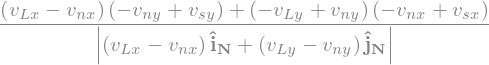

In [3]:
vd_s = 1 / abs(vl - vn) * dot(cross(s, vl - vn), (vs - vn))
vd_s

If we shift coordinate system so that locally $\bv_n = 0$, we can repeat the same exact steps from the paper and so
$$\mathbf{F}_v = \rho_s \kappa \mathbf{s} \times (\bv_L - \bv_s) - \rho_s \kappa \Gamma (\bv_L - \bv_n) - \gamma_0 (\bv_L - \bv_n) - \gamma_0' \mathbf{s} \times (\bv_L - \bv_n) = 0,$$
here $\Gamma = \beta / \sqrt{1 - \beta^2}$ and crucially $\beta = v_d / |\bv_s - \bv_n|$. From here we need only to calculate the adjusted coefficients $\alpha$ and $\alpha'$.

Furthermore:
$$\bv_L = (1-\hat{\alpha}')(\bv_s - \bv_n) - \hat{\alpha}s\times (\bv_s - \bv_n) + \bv_n$$

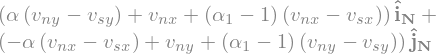

In [8]:
_alphap, _alpha = sp.symbols('\\alpha_{1} \\alpha', real=True)
vl_final = (1 - _alphap) * (vs - vn) + _alpha * cross(s, vs - vn) + vn
vl_final = sp.simplify(vl_final)
vl_final

In the end, it seems viable to just cache $\bv - \mathbf{\omega} \times \mathbf{r}$ and calculate the movement as usual.